In [1]:
import pandas as pd

case = "TCGA-3C-AALK-01Z-00-DX1"
df = pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/BRCA/organized_RNA_seq/"+case+"/ae8996bd-b0b7-4f9b-91fa-606f95d49f8c.rna_seq.augmented_star_gene_counts.tsv", sep="\t", skiprows=1, header=0)
df = df[4:]
df

,gene_id,gene_name,gene_type,unstranded,stranded_first,stranded_second,tpm_unstranded,fpkm_unstranded,fpkm_uq_unstranded
4,ENSG00000000003.15,TSPAN6,protein_coding,2969,1490,1479,42.6138,12.8083,13.6064
5,ENSG00000000005.6,TNMD,protein_coding,4,3,1,0.1764,0.0530,0.0563
6,ENSG00000000419.13,DPM1,protein_coding,1386,704,682,74.7599,22.4704,23.8706
7,ENSG00000000457.14,SCYL3,protein_coding,1315,1081,1076,12.4383,3.7386,3.9715
8,ENSG00000000460.17,C1orf112,protein_coding,460,638,713,5.0164,1.5078,1.6017
...,...,...,...,...,...,...,...,...,...
60659,ENSG00000288669.1,AC008763.4,protein_coding,0,0,0,0.0000,0.0000,0.0000
60660,ENSG00000288670.1,AL592295.6,lncRNA,277,142,144,9.9801,2.9997,3.1866
60661,ENSG00000288671.1,AC006486.3,protein_coding,0,0,0,0.0000,0.0000,0.0000
60662,ENSG00000288674.1,AL391628.1,protein_coding,14,8,6,0.0947,0.0285,0.0303


In [2]:
brca_df = df[["gene_id", "tpm_unstranded"]]
brca_df["gene_id"] = brca_df["gene_id"].str.split('.', expand=True)[0]
brca_df = brca_df.drop_duplicates(subset=["gene_id"])
brca_df

/tmp/ipykernel_172607/476086700.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brca_df["gene_id"] = brca_df["gene_id"].str.split('.', expand=True)[0]


,gene_id,tpm_unstranded
4,ENSG00000000003,42.6138
5,ENSG00000000005,0.1764
6,ENSG00000000419,74.7599
7,ENSG00000000457,12.4383
8,ENSG00000000460,5.0164
...,...,...
60659,ENSG00000288669,0.0000
60660,ENSG00000288670,9.9801
60661,ENSG00000288671,0.0000
60662,ENSG00000288674,0.0947


In [3]:
brca_df['gene_id'].values 

array(['ENSG00000000003', 'ENSG00000000005', 'ENSG00000000419', ...,
       'ENSG00000288671', 'ENSG00000288674', 'ENSG00000288675'],
      dtype=object)

In [4]:
# Create a new DataFrame with "gene_id" as column names and "tpm_unstranded" as values
new_brca_df = pd.DataFrame(columns=brca_df['gene_id'].values, data=[brca_df['tpm_unstranded'].values], index=[case])
new_brca_df

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000288661,ENSG00000288662,ENSG00000288663,ENSG00000288665,ENSG00000288667,ENSG00000288669,ENSG00000288670,ENSG00000288671,ENSG00000288674,ENSG00000288675
TCGA-3C-AALK-01Z-00-DX1,42.6138,0.1764,74.7599,12.4383,5.0164,7.3921,21.7995,35.2978,10.9691,43.5626,...,0.0,0.0,0.5027,0.0,1.0673,0.0,9.9801,0.0,0.0947,2.0927


In [5]:
import warnings

# Filter or ignore specific warning categories
warnings.filterwarnings("ignore")
from glob import glob
from tqdm import tqdm

all_rna_file_path = glob("/data1/r20user3/shared_project/Hist2Cell/data/BRCA/organized_RNA_seq/*/*.rna_seq.augmented_star_gene_counts.tsv")
case_rna_df_list = []
for rna_file_path in tqdm(all_rna_file_path):
    case = rna_file_path.split("/")[-2]
    df = pd.read_csv(rna_file_path, sep="\t", skiprows=1, header=0)
    df = df[4:]
    brca_df = df[["gene_id", "tpm_unstranded"]]
    brca_df["gene_id"] = brca_df["gene_id"].str.split('.', expand=True)[0]
    brca_df = brca_df.drop_duplicates(subset=["gene_id"])
    new_brca_df = pd.DataFrame(columns=brca_df['gene_id'].values, data=[brca_df['tpm_unstranded'].values], index=[case])
    case_rna_df_list.append(new_brca_df)

100%|██████████| 880/880 [08:12<00:00,  1.79it/s]


In [6]:
all_case_rna_df = pd.concat(case_rna_df_list, join='inner')
all_case_rna_df

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000288661,ENSG00000288662,ENSG00000288663,ENSG00000288665,ENSG00000288667,ENSG00000288669,ENSG00000288670,ENSG00000288671,ENSG00000288674,ENSG00000288675
TCGA-A8-A09R-01Z-00-DX1,9.9854,0.2826,115.0461,29.2400,9.7531,11.5599,41.3817,78.0335,20.9121,72.0917,...,0.0,0.0000,0.3033,0.0,0.977,0.0000,29.6830,0.0,0.0805,0.7804
TCGA-E2-A1IE-01Z-00-DX1,34.5847,1.1065,129.3534,14.4737,7.6050,3.9460,10.1275,46.4962,10.3253,84.8503,...,0.0,0.7777,0.4421,0.0,0.000,0.0000,12.4982,0.0,0.0146,0.5555
TCGA-AR-A1AT-01Z-00-DX1,28.3693,0.1866,92.0135,15.0553,8.4406,13.4883,28.8008,65.7654,10.5013,45.0618,...,0.0,0.0000,0.0966,0.0,0.000,0.0000,26.3115,0.0,0.0286,0.6010
TCGA-A2-A0CP-01Z-00-DX1,23.9018,0.8334,62.8190,5.5016,1.6630,6.9363,23.3521,42.0305,6.8102,27.3883,...,0.0,0.0000,0.3237,0.0,0.000,0.0441,7.9739,0.0,0.0365,1.9350
TCGA-XX-A89A-01Z-00-DX1,30.5954,53.6310,78.1094,11.0614,5.3765,19.6006,42.9337,50.8266,15.6718,34.5035,...,0.0,0.0000,0.4898,0.0,0.000,0.0194,5.9639,0.0,0.0887,1.3845
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-AN-A0XN-01Z-00-DX1,36.3313,0.1148,154.5065,8.5923,5.0383,12.4514,52.0587,65.2734,10.9230,57.6942,...,0.0,0.0000,0.2230,0.0,0.000,0.0000,16.6458,0.0,0.0440,0.1513
TCGA-AO-A0JD-01Z-00-DX1,60.3483,0.5546,180.0561,14.4989,18.7501,8.4510,6.5820,230.5040,21.3157,82.1567,...,0.0,0.0000,0.0598,0.0,0.000,0.0000,7.1724,0.0,0.0071,0.7715
TCGA-C8-A132-01Z-00-DX1,27.1198,0.3767,113.9529,14.7321,5.5065,11.3231,37.1017,59.7230,10.9275,56.1510,...,0.0,0.0000,0.2195,0.0,0.000,0.0000,9.1539,0.0,0.0072,0.9101
TCGA-GM-A3XL-01Z-00-DX1,19.3988,0.1661,178.5804,7.4212,12.0377,17.8720,5.1171,47.1452,10.8020,29.0449,...,0.0,0.0000,0.2839,0.0,0.000,0.0000,12.2350,0.0,0.0459,2.6553


In [7]:
all_case_rna_df.to_csv("BRCA_all_case_RNA_seq_tpm.csv")

In [8]:
import scanpy as sc
import numpy as np
import anndata as ad
from scipy.sparse import csr_matrix
import glob
import pandas as pd
import os


# spots_coord = spots_coord.loc[cnt.index]
# location = np.matrix(spots_coord.values)

Xdense = np.matrix(np.round(all_case_rna_df.values))

# batch = np.array([sample.split('/')[-1] for i in range(Xdense.shape[0])])

X = csr_matrix(Xdense, dtype=np.float32)

# adata_vis = ad.AnnData(X, obsm={"spatial": location}, obs={"sample": batch})
adata_vis = ad.AnnData(X)

adata_vis.obs_names = list(all_case_rna_df.index)
# adata_vis.obs_names = list(spots_coord.index)
adata_vis.var_names = list(all_case_rna_df.columns)
adata_vis

AnnData object with n_obs × n_vars = 880 × 60616

In [9]:
import scanpy as sc
import pandas as pd

results_folder = '/data1/r20user3/shared_project/Hist2Cell/code/data_preprocessing/brca_cellabundance'
ref_run_name = f'{results_folder}/breast_reference_signatures'
adata_file = f"{ref_run_name}/breast_sc.h5ad"
adata_ref = sc.read_h5ad(adata_file)
gene_name_df = pd.DataFrame(data=adata_ref.var['feature_name'].index, index=adata_ref.var['feature_name'])
gene_name_df

,0
feature_name,
SAMD11,ENSG00000187634
NOC2L,ENSG00000188976
PLEKHN1,ENSG00000187583
HES4,ENSG00000188290
ISG15,ENSG00000187608
...,...
MT-ND6,ENSG00000198695
MT-CYB,ENSG00000198727
ENSG00000277836.1,ENSG00000277836


In [10]:
import pandas as pd

results_folder = '/data1/r20user3/shared_project/Hist2Cell/code/data_preprocessing/brca_cellabundance'
ref_run_name = f'{results_folder}/breast_reference_signatures'
inf_aver = pd.read_csv(f"{ref_run_name}/inf_aver.csv", index_col=0)
inf_aver

,CD4-positive helper T cell,"CD4-positive, alpha-beta T cell","CD8-positive, alpha-beta memory T cell",IgA plasma cell,IgG plasma cell,T cell,"activated CD4-positive, alpha-beta T cell","activated CD8-positive, alpha-beta T cell",alternatively activated macrophage,basal cell,...,naive B cell,natural killer cell,neutrophil,non-classical monocyte,pericyte,plasmacytoid dendritic cell,regulatory T cell,unswitched memory B cell,vascular associated smooth muscle cell,vein endothelial cell
ENSG00000187634,0.000093,0.000581,0.000117,0.009697,0.016521,0.011125,0.000777,0.002233,0.000466,0.001486,...,0.000874,0.000793,0.002455,0.003843,0.000389,0.012424,0.000729,0.003924,0.002251,0.001459
ENSG00000188976,0.106048,0.131753,0.096779,0.104724,0.053952,0.463471,0.082513,0.064156,0.109238,0.388398,...,0.101240,0.131011,0.006719,0.156448,0.138161,0.018169,0.115740,0.283628,0.114943,0.396417
ENSG00000187583,0.008234,0.001075,0.002133,0.041747,0.040852,0.006904,0.002494,0.004043,0.001658,0.006703,...,0.001394,0.001101,0.002246,0.003335,0.000336,0.018018,0.003701,0.004643,0.002462,0.000642
ENSG00000188290,0.061752,0.018444,0.039539,0.030123,0.036096,0.255466,0.029147,0.015842,0.114556,0.069556,...,0.030032,0.075480,0.030143,2.191927,1.037155,0.033304,0.035726,0.043540,2.457314,0.228936
ENSG00000187608,0.407089,0.358154,0.395427,0.411530,0.256631,1.488990,0.161144,0.128716,0.202869,0.017266,...,0.133318,0.498599,0.076378,1.721559,1.324553,0.134995,0.533212,0.176921,0.794023,1.597615
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000198695,0.626568,0.970354,0.631765,1.517173,0.737683,2.742186,0.134341,0.035507,0.661386,0.627707,...,0.544316,0.450942,0.039699,0.747105,0.468775,0.099835,0.613969,0.956590,0.325175,1.119229
ENSG00000198727,15.226505,27.210596,18.416994,44.024426,25.977613,39.081062,5.267413,5.287973,27.453836,37.355072,...,17.982685,16.419443,2.436880,37.075516,27.753080,5.126897,19.289898,26.682991,33.591920,51.773900
ENSG00000277836,0.554747,0.721732,0.382288,0.945958,0.926648,0.940933,0.873172,0.937858,0.957862,0.054655,...,0.945299,0.798524,0.830856,1.020750,0.595761,0.985082,0.983098,1.035747,0.518004,0.387490
ENSG00000277856,0.000056,0.000424,0.000097,0.265905,0.738255,0.197540,0.000627,0.011215,0.000276,0.000021,...,0.002830,0.000458,0.006993,0.005297,0.000060,0.351953,0.000638,0.014972,0.000063,0.000044


In [11]:
# find shared genes and subset both anndata and reference signatures
intersect = np.intersect1d(adata_vis.var_names, adata_ref.var_names)

adata_vis = adata_vis[:, intersect].copy()
# gene_id = gene_name_df.loc[adata_vis.var_names]
# adata_vis.var_names = gene_id[0]
inf_aver = inf_aver.loc[adata_vis.var_names, :].copy()

In [12]:
import cell2location

# prepare anndata for cell2location model
cell2location.models.Cell2location.setup_anndata(adata=adata_vis)
# create and train the model
mod = cell2location.models.Cell2location(
    adata_vis, cell_state_df=inf_aver, 
    # the expected average cell abundance: tissue-dependent 
    # hyper-prior which can be estimated from paired histology:
    N_cells_per_location=30,
    # hyperparameter controlling normalisation of
    # within-experiment variation in RNA detection:
    detection_alpha=20
) 
mod.view_anndata_setup()

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Anndata setup with scvi-tools version 1.0.4.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': None,
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │  880  │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 13199 │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_batch'] │     0      │          0          │
└──────────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Epoch 30000/30000: 100%|██████████| 30000/30000 [44:50<00:00, 11.12it/s, v_num=1, elbo_train=3.87e+7]

`Trainer.fit` stopped: `max_epochs=30000` reached.


Epoch 30000/30000: 100%|██████████| 30000/30000 [44:50<00:00, 11.15it/s, v_num=1, elbo_train=3.87e+7]


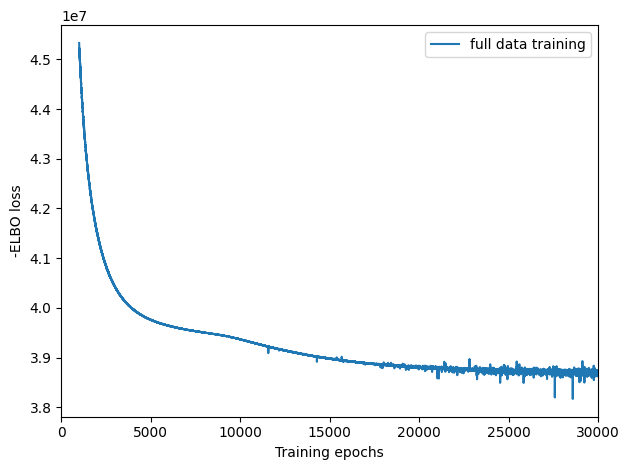

In [13]:
import matplotlib.pyplot as plt

mod.train(max_epochs=30000,  
          # train using full data (batch_size=None)
          batch_size=None, 
          # use all data points in training because 
          # we need to estimate cell abundance at all locations
          train_size=1,
          use_gpu=True,
         )

# plot ELBO loss history during training, removing first 100 epochs from the plot
mod.plot_history(1000)
plt.legend(labels=['full data training'])

In [14]:
# In this section, we export the estimated cell abundance (summary of the posterior distribution).
adata_vis = mod.export_posterior(
    adata_vis, sample_kwargs={'num_samples': 1000, 'batch_size': mod.adata.n_obs, 'use_gpu': True}
)

Sampling global variables, sample: 100%|██████████| 999/999 [00:11<00:00, 89.75it/s]


In [15]:
adata_vis.obsm['q95_cell_abundance_w_sf']

,q95cell_abundance_w_sf_CD4-positive helper T cell,"q95cell_abundance_w_sf_CD4-positive, alpha-beta T cell","q95cell_abundance_w_sf_CD8-positive, alpha-beta memory T cell",q95cell_abundance_w_sf_IgA plasma cell,q95cell_abundance_w_sf_IgG plasma cell,q95cell_abundance_w_sf_T cell,"q95cell_abundance_w_sf_activated CD4-positive, alpha-beta T cell","q95cell_abundance_w_sf_activated CD8-positive, alpha-beta T cell",q95cell_abundance_w_sf_alternatively activated macrophage,q95cell_abundance_w_sf_basal cell,...,q95cell_abundance_w_sf_naive B cell,q95cell_abundance_w_sf_natural killer cell,q95cell_abundance_w_sf_neutrophil,q95cell_abundance_w_sf_non-classical monocyte,q95cell_abundance_w_sf_pericyte,q95cell_abundance_w_sf_plasmacytoid dendritic cell,q95cell_abundance_w_sf_regulatory T cell,q95cell_abundance_w_sf_unswitched memory B cell,q95cell_abundance_w_sf_vascular associated smooth muscle cell,q95cell_abundance_w_sf_vein endothelial cell
TCGA-A8-A09R-01Z-00-DX1,0.107120,0.079679,0.185321,0.054518,0.092955,0.301570,0.267943,0.612449,0.241439,2.555976,...,0.118120,0.153908,0.349440,0.163574,0.405438,0.159432,0.245521,0.100176,0.954523,0.078583
TCGA-E2-A1IE-01Z-00-DX1,0.040614,0.016393,0.023487,0.008002,0.005021,0.019820,0.028633,0.022511,0.103055,0.381556,...,0.010281,0.011448,0.007840,0.008055,0.226888,0.002561,0.005836,0.005247,0.865280,0.106980
TCGA-AR-A1AT-01Z-00-DX1,0.152650,0.248916,0.076219,0.043907,0.456949,0.124016,0.325953,0.661066,0.155648,0.427150,...,0.136038,0.253378,0.418451,0.056778,0.592709,0.394876,0.372946,0.231957,0.271483,0.202049
TCGA-A2-A0CP-01Z-00-DX1,0.061452,0.057051,0.025397,0.079909,0.024548,0.000649,0.065983,0.062530,0.038467,0.837128,...,0.015276,0.014942,0.050250,0.008200,0.096212,0.072969,0.014060,0.008672,0.500143,0.193953
TCGA-XX-A89A-01Z-00-DX1,0.268277,0.213489,0.034558,0.199543,0.070568,0.011209,0.638779,0.456155,0.864833,0.429237,...,0.107201,0.095978,0.661475,0.075327,0.412312,0.317936,0.238422,0.062295,0.666966,0.217422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-AN-A0XN-01Z-00-DX1,0.399323,0.087965,0.145445,0.004102,0.019066,0.054970,0.173815,0.354687,0.846795,3.363211,...,0.022877,0.058208,0.804521,0.130821,1.373796,0.017303,0.284608,0.051902,1.805371,0.042535
TCGA-AO-A0JD-01Z-00-DX1,0.056845,0.073311,0.135574,0.021616,0.056946,0.382516,0.077320,0.101581,0.033923,0.391268,...,0.076446,0.017194,0.091667,0.018028,0.261372,0.010908,0.142888,0.056088,0.179870,0.077604
TCGA-C8-A132-01Z-00-DX1,0.205699,0.332575,0.138932,0.350525,0.826957,0.115407,0.748626,1.961005,0.669838,3.308293,...,0.364824,0.464925,0.539484,0.129915,0.847157,0.561463,0.655485,0.464001,0.734535,0.356819
TCGA-GM-A3XL-01Z-00-DX1,0.005619,0.004616,0.088507,0.052700,0.249119,0.277232,0.016808,0.047358,0.002727,0.004389,...,0.013127,0.069228,0.018471,0.022799,0.004767,0.009265,0.007622,0.031411,0.002787,0.001289


In [16]:
adata_vis.write('brca_cellabundance_estimation.h5ad')

In [ ]:
import pandas as pd

df = pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/code/data_preprocessing/brca_cellabundance/de01516e-43f0-4f96-8ac6-ab543a314829.rna_seq.augmented_star_gene_counts.tsv", sep="\t", header=0)
df

In [ ]:
df.head(10)

,gene_id,gene_name,gene_type,unstranded,stranded_first,stranded_second,tpm_unstranded,fpkm_unstranded,fpkm_uq_unstranded
0,N_unmapped,NaN,NaN,2996570,2996570,2996570,NaN,NaN,NaN
1,N_multimapping,NaN,NaN,4910246,4910246,4910246,NaN,NaN,NaN
2,N_noFeature,NaN,NaN,60362311,79902238,61209264,NaN,NaN,NaN
3,N_ambiguous,NaN,NaN,1906634,24272,1174541,NaN,NaN,NaN
4,ENSG00000000003.15,TSPAN6,protein_coding,691,0,691,29.6290,9.2344,8.4180
5,ENSG00000000005.6,TNMD,protein_coding,20,14,6,2.6355,0.8214,0.7488
6,ENSG00000000419.13,DPM1,protein_coding,335,5,330,53.9820,16.8244,15.3370
7,ENSG00000000457.14,SCYL3,protein_coding,1292,351,1481,36.5087,11.3785,10.3726
8,ENSG00000000460.17,C1orf112,protein_coding,536,479,614,17.4623,5.4424,4.9613
9,ENSG00000000938.13,FGR,protein_coding,56,0,56,3.2205,1.0037,0.9150


In [ ]:
brca_df = df[["gene_id", "unstranded"]].iloc[4:]
brca_df["gene_id"] = brca_df["gene_id"].str.split('.', expand=True)[0]
brca_df = brca_df.groupby('gene_id').sum().reset_index()
brca_df

,gene_id,unstranded
0,ENSG00000000003,691
1,ENSG00000000005,20
2,ENSG00000000419,335
3,ENSG00000000457,1292
4,ENSG00000000460,536
...,...,...
60611,ENSG00000288669,0
60612,ENSG00000288670,222
60613,ENSG00000288671,0
60614,ENSG00000288674,3


In [ ]:
len(set(brca_df["gene_id"]))

60616

In [ ]:
import scanpy as sc
import numpy as np
import anndata as ad
from scipy.sparse import csr_matrix
import glob
import pandas as pd
import os


# spots_coord = spots_coord.loc[cnt.index]
# location = np.matrix(spots_coord.values)

Xdense = np.matrix(brca_df["unstranded"].values)
Xdense_2 = np.stack([Xdense, Xdense])

# batch = np.array([sample.split('/')[-1] for i in range(Xdense.shape[0])])

X = csr_matrix(Xdense_2, dtype=np.float32)

# adata_vis = ad.AnnData(X, obsm={"spatial": location}, obs={"sample": batch})
adata_vis = ad.AnnData(X)

adata_vis.obs_names = ["caseA", "caseB"]
# adata_vis.obs_names = list(spots_coord.index)
adata_vis.var_names = list(brca_df["gene_id"])

In [ ]:
adata_vis

AnnData object with n_obs × n_vars = 2 × 60616